In [2]:
import os 
os.chdir("/scale/user/mtannaou/alternance")
os.getcwd()

'/scale/user/mtannaou/alternance'

In [3]:
import numpy as np;import pandas as pd;import matplotlib.pyplot as plt;import pickle as pkl;import torch
from tqdm import tqdm
from src.IR_to_SAR.data_preparation.distribution_data_visualisation import plot_sar,plot_ir

## Make the predctions of test and anggrek sets with the regression model

UNETSARGEO 35 (IR(9) + ERA5(t=0) ---> WIND)

In [4]:
name_pkl = "predictions_denormalisées.pkl"

In [5]:
prediction_denorm_path_reg = "/scale/user/mtannaou/alternance/src/IR_to_SAR/ML_IR_SAR/UNETSARGEO/train_ir_sar_35/predictions_denormalisees"
test_reg_path = os.path.join(prediction_denorm_path_reg,"test")
anggrek_reg_path = os.path.join(prediction_denorm_path_reg,"anggrek")
with open(os.path.join(test_reg_path,name_pkl),"rb") as f:
    test_reg_pkl = pkl.load(f)["test"]
#anggrek pkl
with open(os.path.join(anggrek_reg_path,name_pkl),"rb") as f:
    anggrek_reg_pkl = pkl.load(f)["<class 'set'>"]
reg_pred_test = test_reg_pkl[2]
reg_pred_anggrek = anggrek_reg_pkl[1]
test_target = test_reg_pkl[1]
ir_test = test_reg_pkl[0]
ir_anggrek = anggrek_reg_pkl[0]
print(reg_pred_anggrek.shape)

(151, 128, 128)


Text(0.5, 1.0, 'Wind Pred (Regression)')

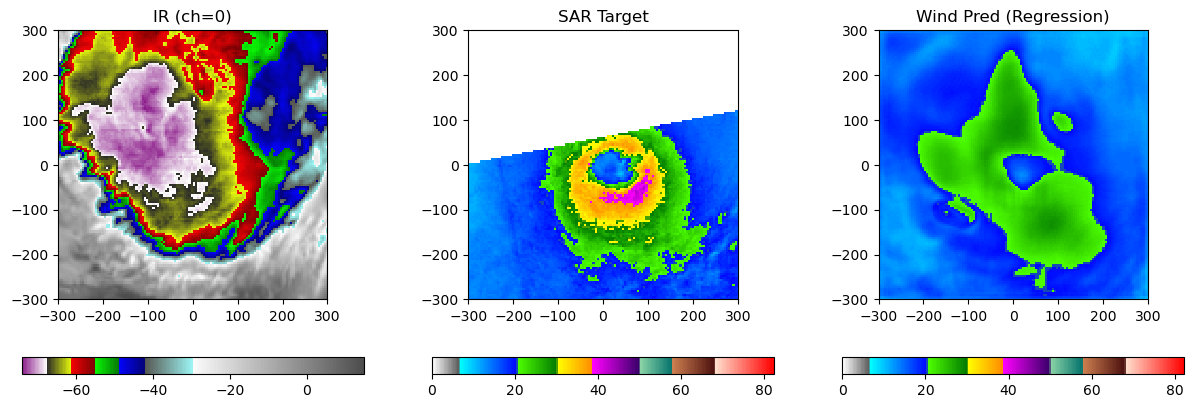

In [6]:
fig_test, axes_test = plt.subplots(1,3,figsize=(15,5))
plot_ir(ir_test[71],fig=fig_test,ax=axes_test[0]);axes_test[0].set_title("IR (ch=0)")
plot_sar(test_target[71],fig=fig_test,ax=axes_test[1]);axes_test[1].set_title("SAR Target")
plot_sar(reg_pred_test[71],fig=fig_test,ax=axes_test[2]);axes_test[2].set_title("Wind Pred (Regression)")

## Get the predictions of the test and anggrek sets with the flow matching model

flow_matching 3

In [7]:
from src.IR_to_SAR.ML_IR_SAR.flow_matching_inference import generate_ensemble, compute_uncertainty_maps,generate_residual_ensemble

In [8]:
#Upload IR testa nd anggrek data
with open("/scale/user/mtannaou/alternance/test_and_anggrek_pkl_data/test_ir.pkl","rb") as f:
    test_10c = pkl.load(f)
test_ir = test_10c[:,:-1,:,:]
with open("/scale/user/mtannaou/alternance/test_and_anggrek_pkl_data/anggrek_ir.pkl","rb") as f:
    anggrek_10c = pkl.load(f)
N_test = test_10c.shape[0] ; N_anggrek = anggrek_10c.shape[0]
anggrek_ir = anggrek_10c[:,:-1,:,:]
era5_anggrek = anggrek_10c[:,-1,:,:].reshape(N_anggrek,1,128,128)
era5_test = test_10c[:,-1,:,:].reshape(N_test,1,128,128)
print("shape of test IR ",test_ir.shape)
print("Shape of test ERA5 :",era5_test.shape)
print("Shape of anggrek IR :",anggrek_ir.shape)
print("SHape of anggrek ERA5 :",era5_anggrek.shape)

shape of test IR  (131, 9, 128, 128)
Shape of test ERA5 : (131, 1, 128, 128)
Shape of anggrek IR : (151, 9, 128, 128)
SHape of anggrek ERA5 : (151, 1, 128, 128)


In [9]:
prediction_denorm_path_fm = "/scale/user/mtannaou/alternance/src/IR_to_SAR/ML_IR_SAR/flow_matching/train_ir_sar_3/predictions_denormalisees"
test_fm_path = os.path.join(prediction_denorm_path_fm,"test")
anggrek_fm_path  = os.path.join(prediction_denorm_path_fm,"anggrek")
#test set 
with open(os.path.join(test_fm_path, name_pkl), "rb") as f:
    data = pkl.load(f)

test_fm_pkl = data["test"]
fm_model = data["model"]
fm_model.eval()
device=fm_model.device
target_test_fm = test_fm_pkl[1];target_test_fm_torch = torch.from_numpy(target_test_fm)
#upload ir test data 

pred_fm = []
#upload the stats for normalisation the ir data
stats_path_fm = "/scale/user/mtannaou/alternance/src/IR_to_SAR/ML_IR_SAR/flow_matching/train_ir_sar_3/stats_normalisation/OUTPUT/stats.pkl"
with open(stats_path_fm,"rb") as f:
    stats = pkl.load(f)
mean_ir = np.array(stats["mean_x"]);std_ir = np.array(stats["std_x"])
mean_sar = np.array(stats["mean_sar"]);std_sar = np.array(stats["std_sar"])
#boucle pour les predictions
pred_fm_mean= [];pred_fm_std = []
for i in tqdm(range(test_ir.shape[0]), desc="Generating test predictions"):
    x_ir = (test_ir[i] - mean_ir[:, None, None]) / std_ir[:, None, None]
    x_ir = torch.from_numpy(x_ir).float().to(device)

    ensemble = generate_ensemble(
        model=fm_model,
        ir_input=x_ir,
        n_members=20,
        num_steps=50,
        device=device
    )
    mean_pred, std_pred = compute_uncertainty_maps(ensemble)
    mean_pred = mean_pred.detach().cpu().numpy()
    std_pred = std_pred.detach().cpu().numpy()

    mean_pred = mean_pred*std_sar + mean_sar
    std_pred = std_pred*std_sar
    pred_fm_mean.append(mean_pred); pred_fm_std.append(std_pred)
pred_fm_mean = np.array(pred_fm_mean);pred_fm_std = np.array(pred_fm_std)

print("Shae of mean prediction is :",pred_fm_mean.shape)
print("Shape of std prediction si :",pred_fm_std.shape)


/home1/datahome/mtannaou/conda-env/data_env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Generating test predictions: 100%|██████████| 131/131 [03:41<00:00,  1.69s/it]


Shae of mean prediction is : (131, 1, 128, 128)
Shape of std prediction si : (131, 1, 128, 128)


Text(0.5, 1.0, 'Flow Matching (Std n=20)')

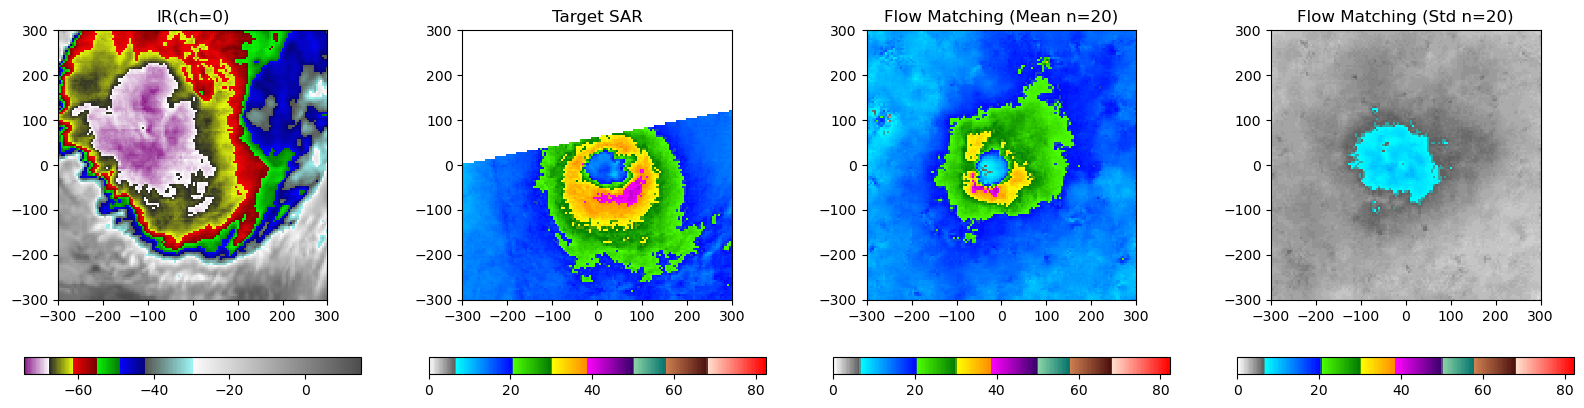

In [10]:
fig_fm,axes_fm = plt.subplots(1,4,figsize=(20,5))
idx_fm = 71
plot_ir(test_ir[idx_fm,0],ax=axes_fm[0],fig=fig_fm);axes_fm[0].set_title("IR(ch=0)")
plot_sar(target_test_fm[idx_fm], ax=axes_fm[1], fig=fig_fm), axes_fm[1].set_title("Target SAR")
plot_sar(test_fm_pkl[2][idx_fm],ax=axes_fm[2],fig=fig_fm);axes_fm[2].set_title("Flow Matching (Mean n=20)")
plot_sar(pred_fm_std[idx_fm][0],ax=axes_fm[3],fig=fig_fm);axes_fm[3].set_title("Flow Matching (Std n=20)")

generate Anggrek predictions

In [11]:
pred_fm_mean_anggrek= [];pred_fm_std_anggrek = []
for i in tqdm(range(anggrek_ir.shape[0]), desc="Generating Anggrek predictions"):
    x_ir = (anggrek_ir[i] - mean_ir[:, None, None]) / std_ir[:, None, None]
    x_ir = torch.from_numpy(x_ir).float().to(device)

    ensemble = generate_ensemble(
        model=fm_model,
        ir_input=x_ir,
        n_members=20,
        num_steps=50,
        device=device
    )
    mean_pred, std_pred = compute_uncertainty_maps(ensemble)
    mean_pred = mean_pred.detach().cpu().numpy()
    std_pred = std_pred.detach().cpu().numpy()

    mean_pred = mean_pred*std_sar + mean_sar
    std_pred = std_pred*std_sar
    pred_fm_mean_anggrek.append(mean_pred); pred_fm_std_anggrek.append(std_pred)
pred_fm_mean_anggrek = np.array(pred_fm_mean_anggrek);pred_fm_std_anggrek = np.array(pred_fm_std_anggrek)

print("Shae of mean prediction is :",pred_fm_mean_anggrek.shape)
print("Shape of std prediction si :",pred_fm_std_anggrek.shape)

Generating Anggrek predictions: 100%|██████████| 151/151 [04:13<00:00,  1.68s/it]


Shae of mean prediction is : (151, 1, 128, 128)
Shape of std prediction si : (151, 1, 128, 128)


## Make the prediction of the test and anggrek sets using residual flow matching

In [12]:
prediction_denorm_path_residual_fm = "/scale/user/mtannaou/alternance/src/IR_to_SAR/ML_IR_SAR/flow_matching_residual/train_ir_sar_1/predictions_denormalisees/test"
with open(os.path.join(prediction_denorm_path_residual_fm,name_pkl),"rb") as f:
    data_residual_fm = pkl.load(f)
residual_fm_model = data_residual_fm["model"]
test_residual_fm_pkl = data_residual_fm["test"]
target_sar_residual_fm = test_residual_fm_pkl[1]

In [13]:
##upload era5 stats for normlisation (mean and std)
stats_for_era5 = "/scale/user/mtannaou/alternance/src/IR_to_SAR/ML_IR_SAR/flow_matching_residual/train_ir_sar_1/stats_normalisation/OUTPUT/stats.pkl"
with open(stats_for_era5,"rb") as f:
    stats_era5 = pkl.load(f)
mean_era5 = np.array(stats_era5["mean_x"])[-1];std_era5 = np.array(stats_era5["std_x"])[-1]
mean_era5, std_era5

(np.float64(14.566257467914927), np.float64(7.415044878522756))

In [14]:
## load regression model (35)
from src.IR_to_SAR.ML_IR_SAR.model import load_regression_model
from src.IR_to_SAR.ML_IR_SAR.config import IR_SAR_Config
from src.IR_to_SAR.data_preparation.data_preprocessing import load_residual_stats
residual_stats = load_residual_stats("/scale/user/mtannaou/alternance/src/IR_to_SAR/ML_IR_SAR/flow_matching_residual/residual_stats.json")

config_path = "/scale/user/mtannaou/alternance/src/IR_to_SAR/ML_IR_SAR/config.yaml"
cfg = IR_SAR_Config.from_yaml(config_path)
reg_model = load_regression_model("/scale/user/mtannaou/alternance/src/IR_to_SAR/ML_IR_SAR/UNETSARGEO/train_ir_sar_35/best_regression_model.pt",
                                  device=device,
                                  cfg=cfg
                                  )
reg_model.eval()
print("regression model loaded")

regression model loaded


In [15]:
pred_residual_fm_test_mean,pred_residual_fm_test_std = [],[]
for i in tqdm(range(test_ir.shape[0]),desc="Generating residual prediction for the test set"):
    x_ir = (test_ir[i] - mean_ir[:, None, None]) / std_ir[:, None, None]
    era5 = (era5_test[i] - mean_era5)/std_era5
    reg_input = np.concatenate([x_ir,era5],axis=0)
    reg_input = torch.from_numpy(reg_input).float().to(device)
    mean_pred_reg = reg_model(reg_input.unsqueeze(0),timestep=0).sample
    mean_pred_reg = mean_pred_reg.to(residual_fm_model.device)
    ensemble = generate_residual_ensemble(fm_model=residual_fm_model,
                                          mean_pred=mean_pred_reg,
                                          n_members=20,
                                          num_steps=50,
                                          residual_mean=residual_stats["mean"],
                                          residual_std=residual_stats["std"])
    mean_pred, std_pred = ensemble.mean(0),ensemble.std(0)
    pred_residual_fm_test_mean.append(mean_pred.detach().cpu().numpy())
    pred_residual_fm_test_std.append(std_pred.detach().cpu().numpy())
pred_residual_fm_test_mean = np.array(pred_residual_fm_test_mean)
pred_residual_fm_test_std = np.array(pred_residual_fm_test_std)
print("Shape of the Residual flow matching mean :",pred_residual_fm_test_mean.shape)
print("Shape of the Residual Flow matching std :",pred_residual_fm_test_std.shape)

# same thing for anggrek
pred_residual_fm_anggrek_mean,pred_residual_fm_anggrek_std = [],[]
for i in tqdm(range(anggrek_ir.shape[0]),desc="Generating residual prediction for the Anggrek set"):
    x_ir = (anggrek_ir[i] - mean_ir[:, None, None]) / std_ir[:, None, None]
    era5 = (era5_anggrek[i] - mean_era5)/std_era5
    reg_input = np.concatenate([x_ir,era5],axis=0)
    reg_input = torch.from_numpy(reg_input).float().to(device)
    mean_pred = reg_model(reg_input.unsqueeze(0),timestep=0).sample
    mean_pred = mean_pred.to(residual_fm_model.device)
    ensemble = generate_residual_ensemble(fm_model=residual_fm_model,
                                          mean_pred=mean_pred,
                                          n_members=20,
                                          num_steps=50,
                                          residual_mean=residual_stats["mean"],
                                          residual_std=residual_stats["std"])
    mean_pred, std_pred = ensemble.mean(0),ensemble.std(0)
    pred_residual_fm_anggrek_mean.append(mean_pred.detach().cpu().numpy())
    pred_residual_fm_anggrek_std.append(std_pred.detach().cpu().numpy())
pred_residual_fm_anggrek_mean = np.array(pred_residual_fm_anggrek_mean)
pred_residual_fm_anggrek_std = np.array(pred_residual_fm_anggrek_std)
print("Shape of the Residual flow matching mean :",pred_residual_fm_anggrek_mean.shape)
print("Shape of the Residual Flow matching std :",pred_residual_fm_anggrek_std.shape)


Generating residual prediction for the test set: 100%|██████████| 131/131 [03:42<00:00,  1.70s/it]


Shape of the Residual flow matching mean : (131, 1, 128, 128)
Shape of the Residual Flow matching std : (131, 1, 128, 128)


Generating residual prediction for the Anggrek set: 100%|██████████| 151/151 [04:13<00:00,  1.68s/it]


Shape of the Residual flow matching mean : (151, 1, 128, 128)
Shape of the Residual Flow matching std : (151, 1, 128, 128)


In [16]:
pred_residual_fm_test_mean_denorm = pred_residual_fm_test_mean*std_sar + mean_sar
pred_residual_fm_test_std_denorm = pred_residual_fm_test_std*std_sar
pred_residual_fm_anggrek_mean_denorm = pred_residual_fm_anggrek_mean*std_sar + mean_sar
pred_residual_fm_anggrek_std_denorm = pred_residual_fm_anggrek_std*std_sar

## Compare all the results (Regression vs Flow matching vs Residual flow matching)

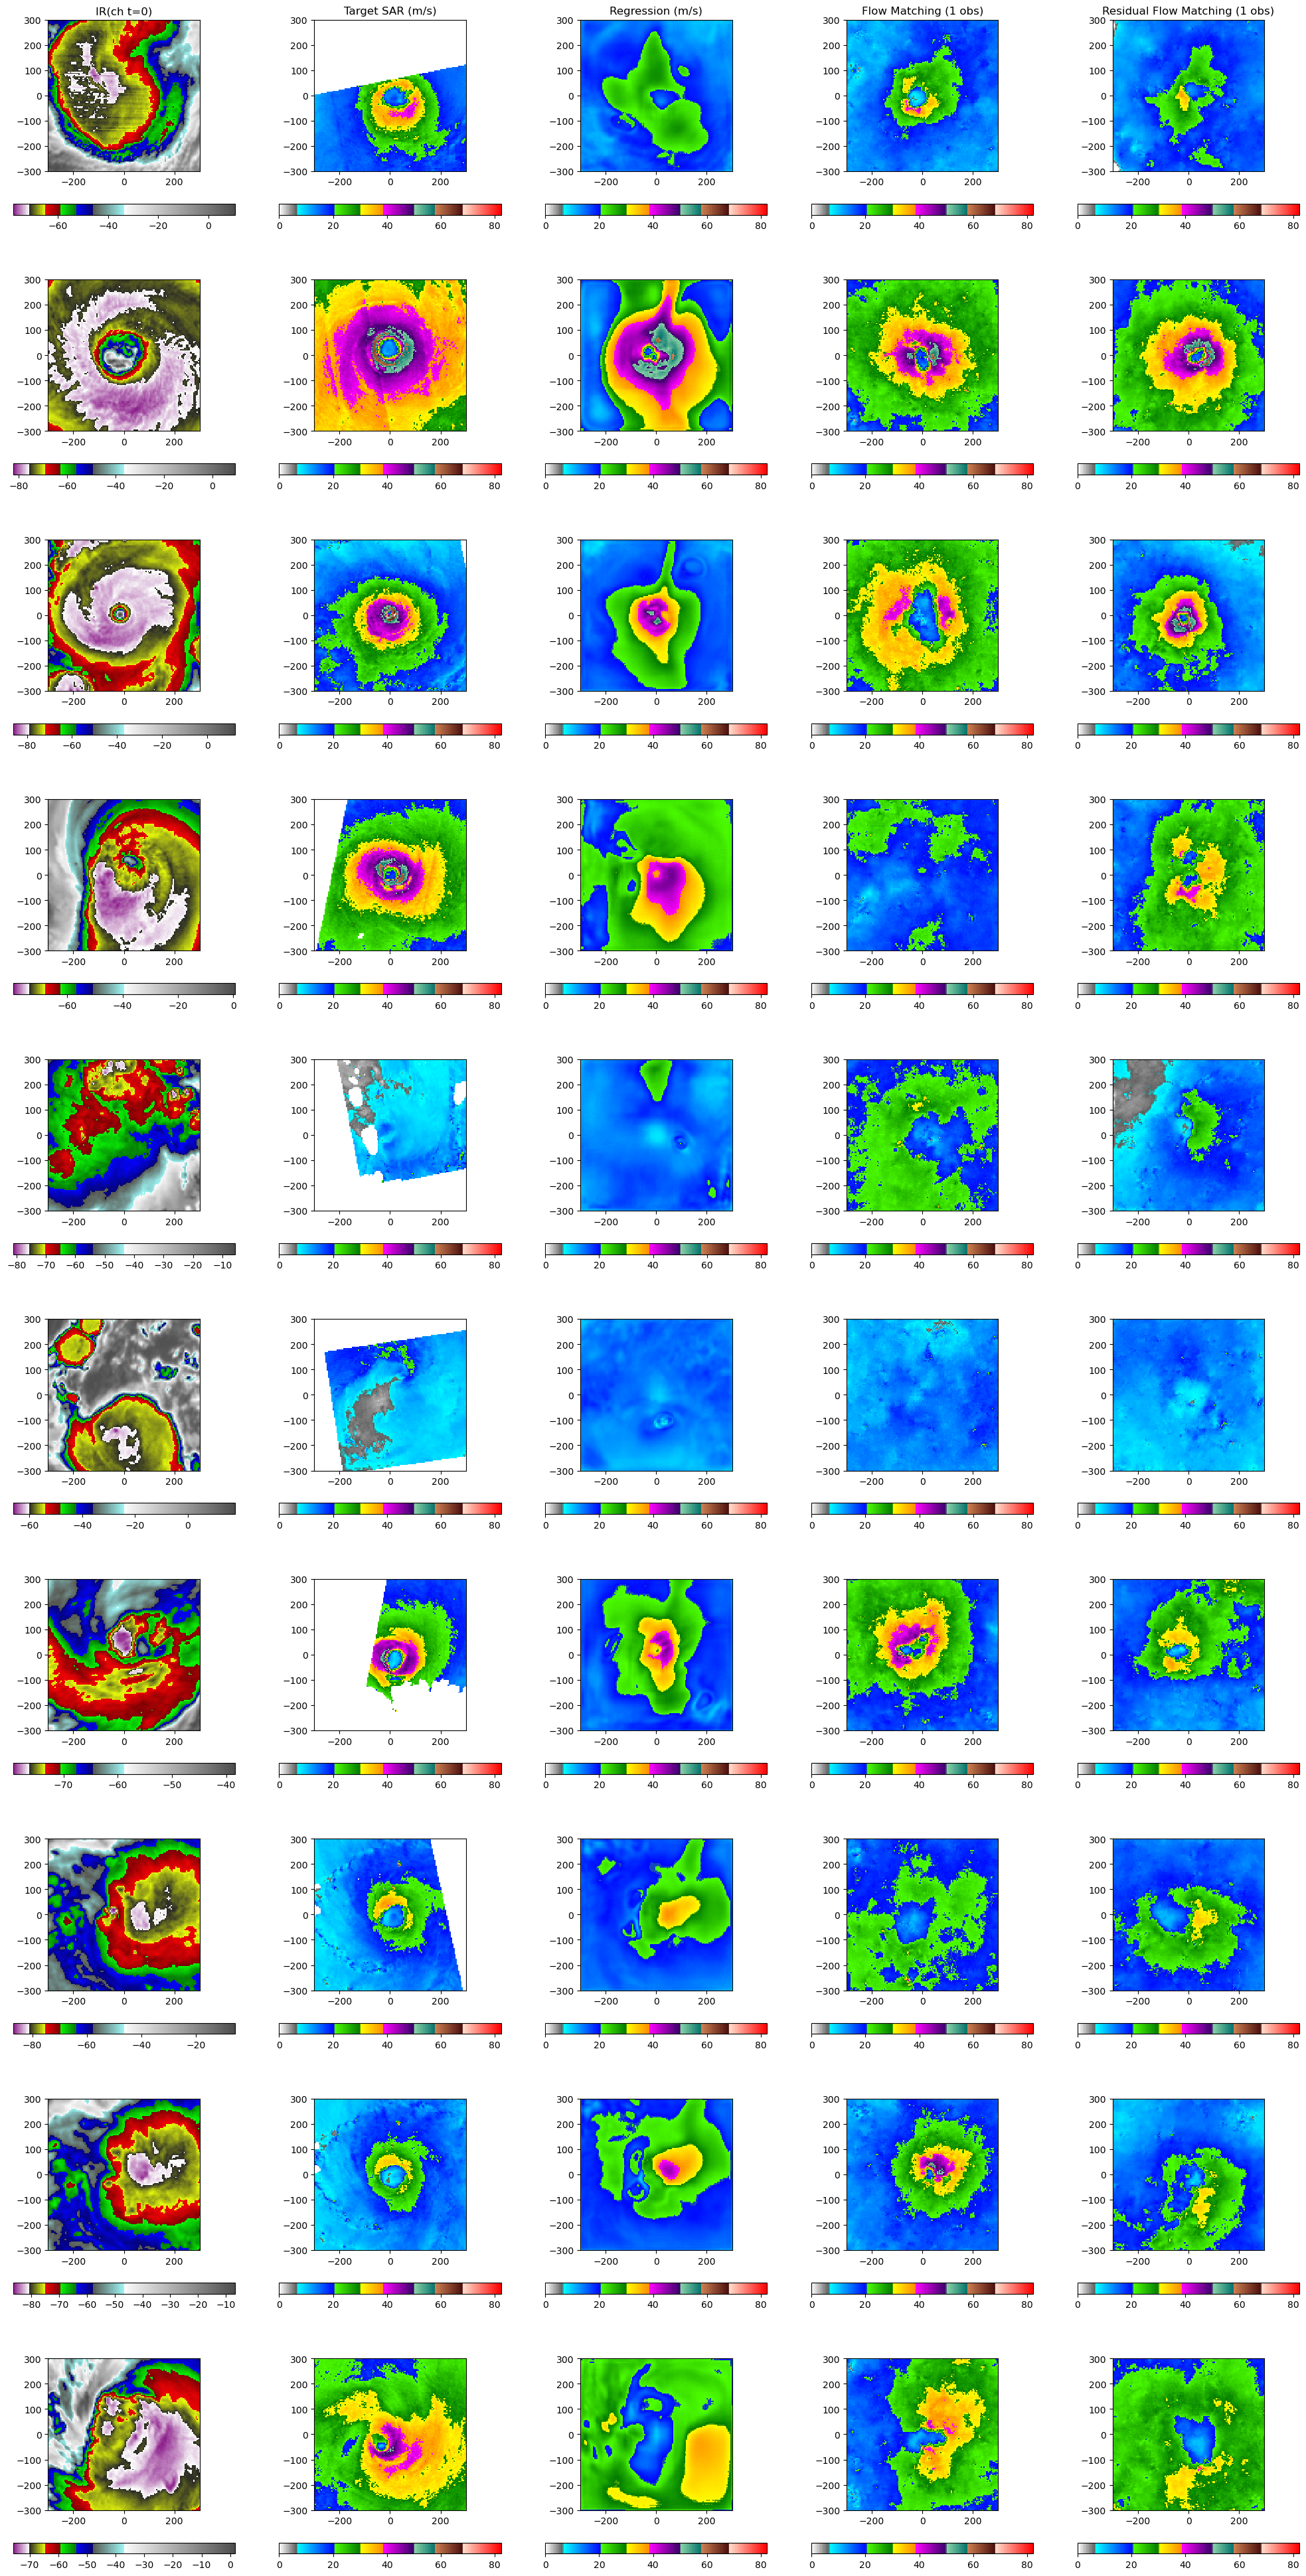

In [17]:
# IR target Regression Flowmatching residual-flowmatching

fig, axes = plt.subplots(10,5,figsize=(25,50))
for enu,i in enumerate([71,50,100,20,48,60,5,10,11,99]):
    plot_ir(test_ir[i,4],ax=axes[enu,0],fig=fig)
    plot_sar(test_target[i],fig=fig,ax=axes[enu,1])
    plot_sar(reg_pred_test[i],fig=fig,ax=axes[enu,2])
    plot_sar(test_fm_pkl[2][i],fig=fig,ax=axes[enu,3])
    plot_sar(test_residual_fm_pkl[2][i],fig=fig,ax=axes[enu,4])
    if enu==0:
        axes[enu,0].set_title("IR(ch t=0)")
        axes[enu,1].set_title("Target SAR (m/s)")
        axes[enu,2].set_title("Regression (m/s)")
        axes[enu,3].set_title("Flow Matching (1 obs)")
        axes[enu,4].set_title("Residual Flow Matching (1 obs)")


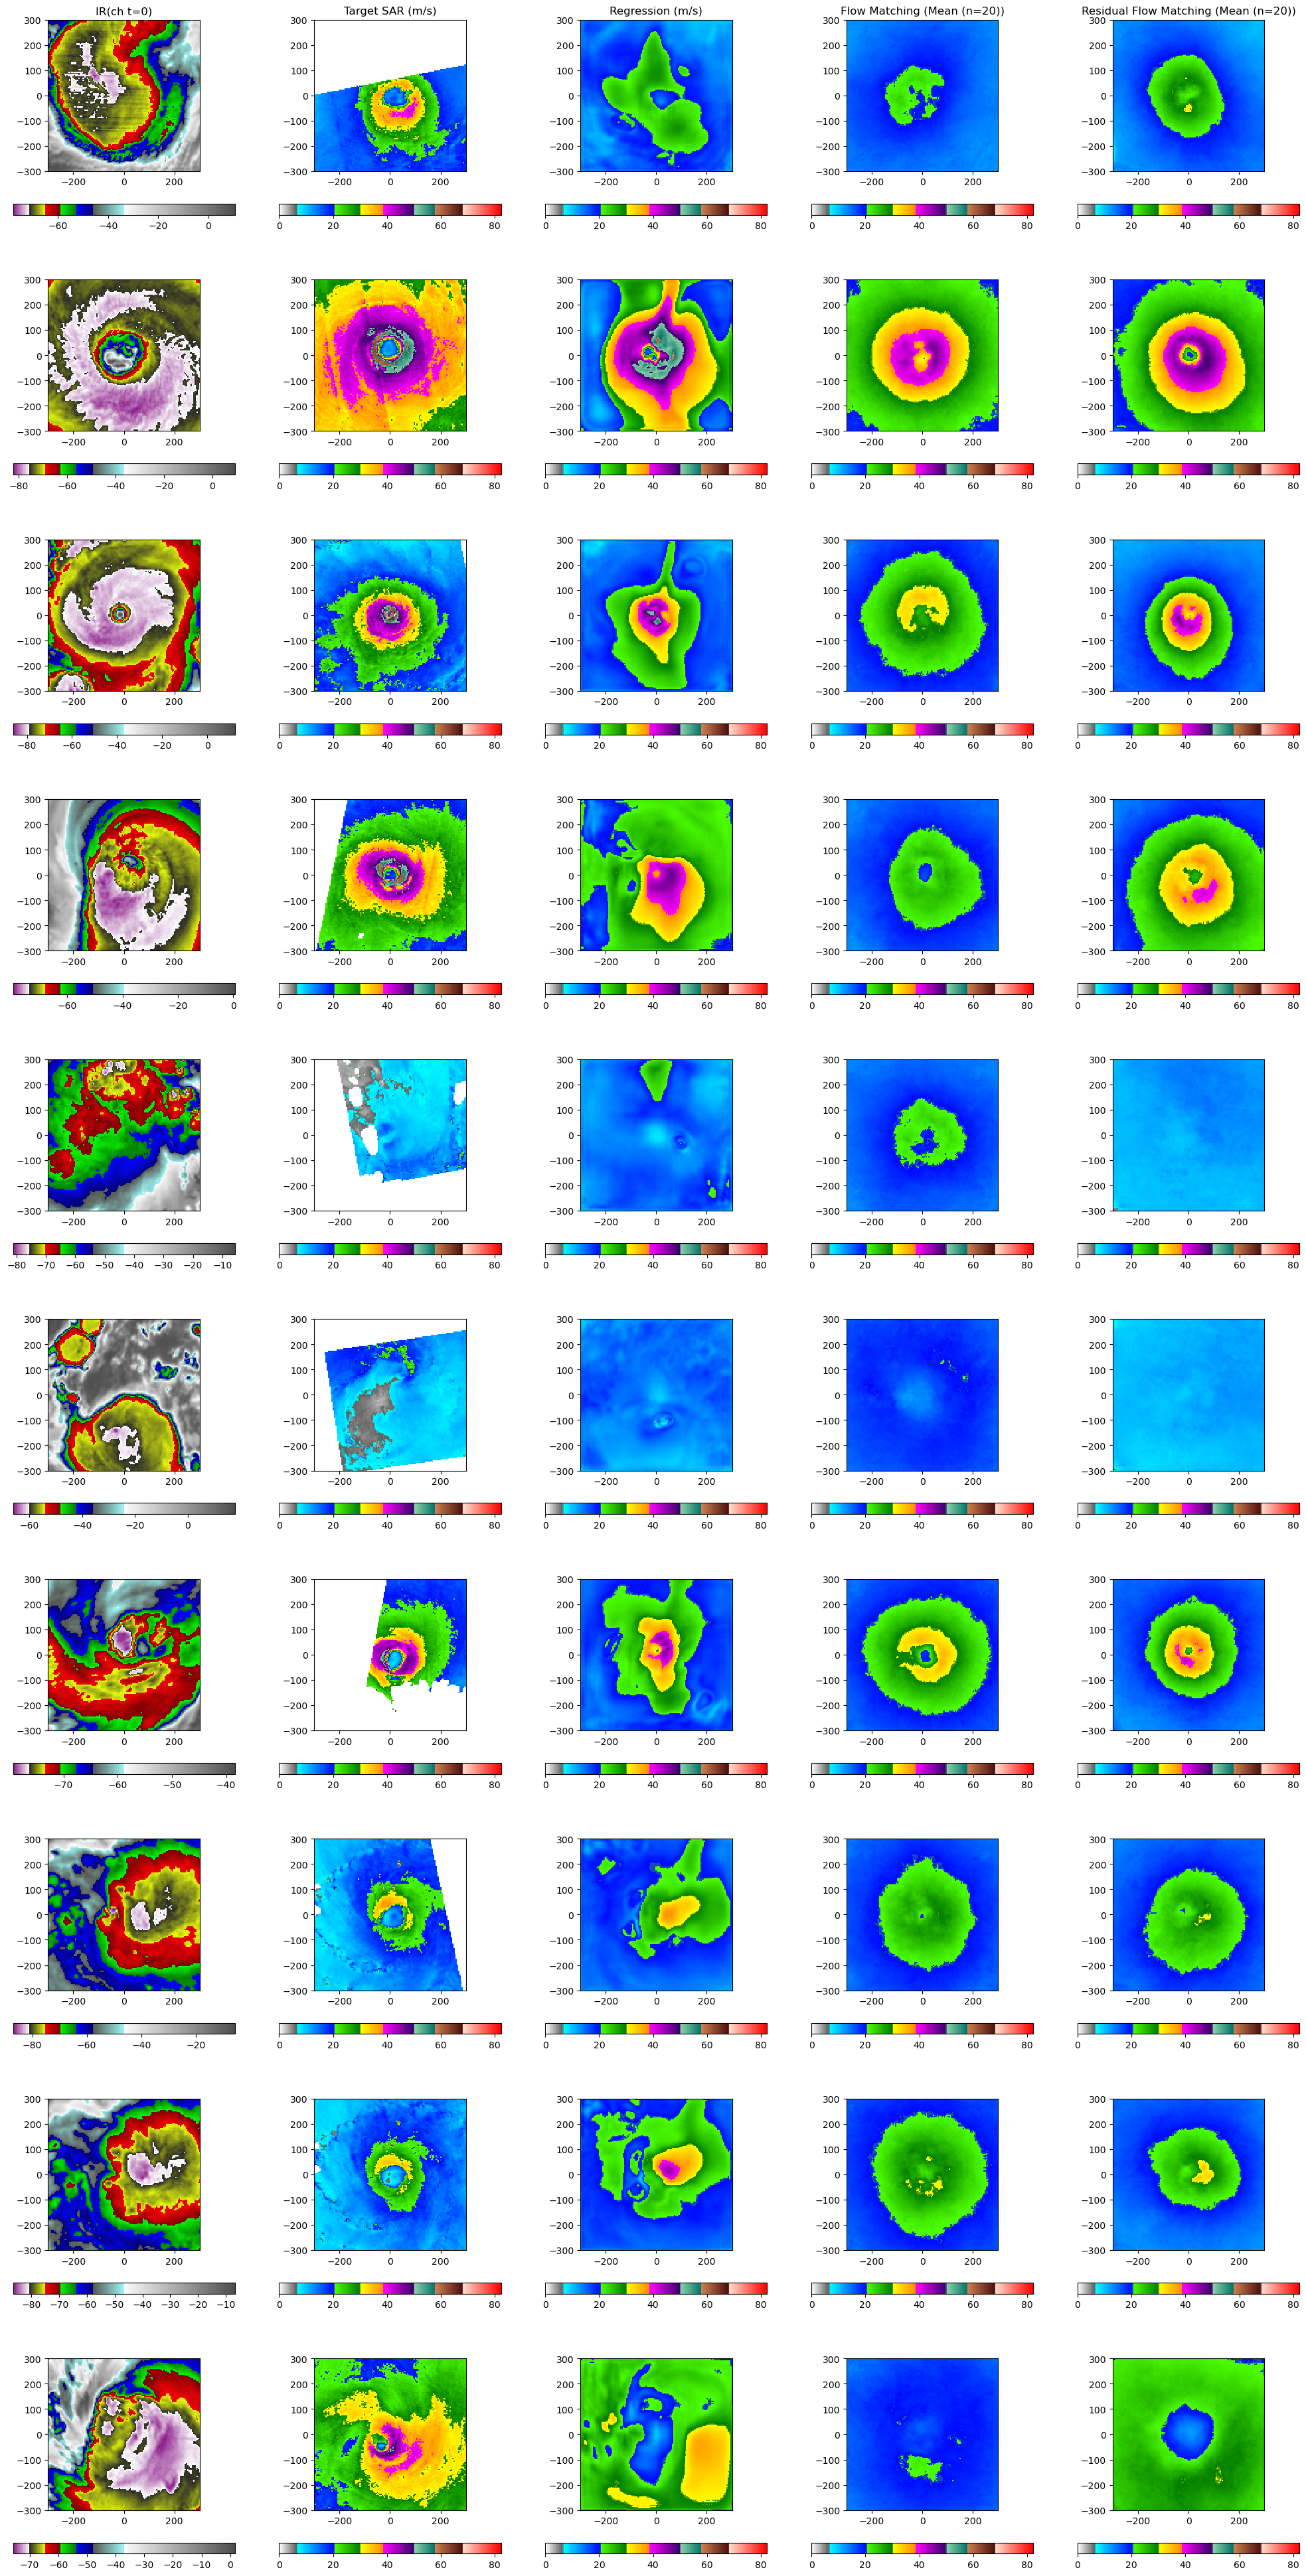

In [18]:

fig, axes = plt.subplots(10,5,figsize=(25,50))
for enu,i in enumerate([71,50,100,20,48,60,5,10,11,99]):
    plot_ir(test_ir[i,4],ax=axes[enu,0],fig=fig)
    plot_sar(test_target[i],fig=fig,ax=axes[enu,1])
    plot_sar(reg_pred_test[i],fig=fig,ax=axes[enu,2])
    plot_sar(pred_fm_mean[i][0],fig=fig,ax=axes[enu,3])
    plot_sar(pred_residual_fm_test_mean_denorm[i][0],fig=fig,ax=axes[enu,4])
    if enu==0:
        axes[enu,0].set_title("IR(ch t=0)")
        axes[enu,1].set_title("Target SAR (m/s)")
        axes[enu,2].set_title("Regression (m/s)")
        axes[enu,3].set_title("Flow Matching (Mean (n=20))")
        axes[enu,4].set_title("Residual Flow Matching (Mean (n=20))")

## Anggrek cycle de vie comparison

In [19]:
anggrek_csv = pd.read_csv("/scale/user/mtannaou/alternance/src/IR_to_SAR/ML_IR_SAR/csv_data/anggrek_coloc_sar_ir.csv")
ibtracs = anggrek_csv["ibtracs_vmax"][1:-1]
dates = anggrek_csv["date"][1:-1]
print(len(ibtracs),len(dates))
#compute vmax for the predictions
mean_fm_vmax, std_fm_vmax = [],[]
reg_vmax = []
mean_res_fm_vmax,std_res_fm_vmax= [],[]
for sar in reg_pred_anggrek:
    reg_vmax.append(np.nanmax(sar))
reg_vmax = np.array(reg_vmax)
print("regression vmax :",reg_vmax.shape)
print("----------------------------")
for sar_mean,std_mean in zip(pred_fm_mean_anggrek,pred_fm_std_anggrek):
    mean_fm_vmax.append(np.nanmax(sar_mean))
    std_fm_vmax.append(np.nanmax(std_mean))
mean_fm_vmax = np.array(mean_fm_vmax)
std_fm_vmax = np.array(std_fm_vmax)
print("Flow matching vmax :",mean_fm_vmax.shape)
print("----------------------------")
for sar_mean,std_mean in zip(pred_residual_fm_anggrek_mean_denorm,pred_residual_fm_anggrek_std_denorm):
    mean_res_fm_vmax.append(np.nanmax(sar_mean))
    std_res_fm_vmax.append(np.nanmax(std_mean))
mean_res_fm_vmax = np.array(mean_res_fm_vmax)
std_res_fm_vmax = np.array(std_res_fm_vmax)
print("Residual Flow Matching vmax :",mean_res_fm_vmax.shape)

151 151
regression vmax : (151,)
----------------------------
Flow matching vmax : (151,)
----------------------------
Residual Flow Matching vmax : (151,)


151 151
Regression vmax : (151,)
Flow matching vmax : (151,)
Residual Flow matching vmax : (151,)


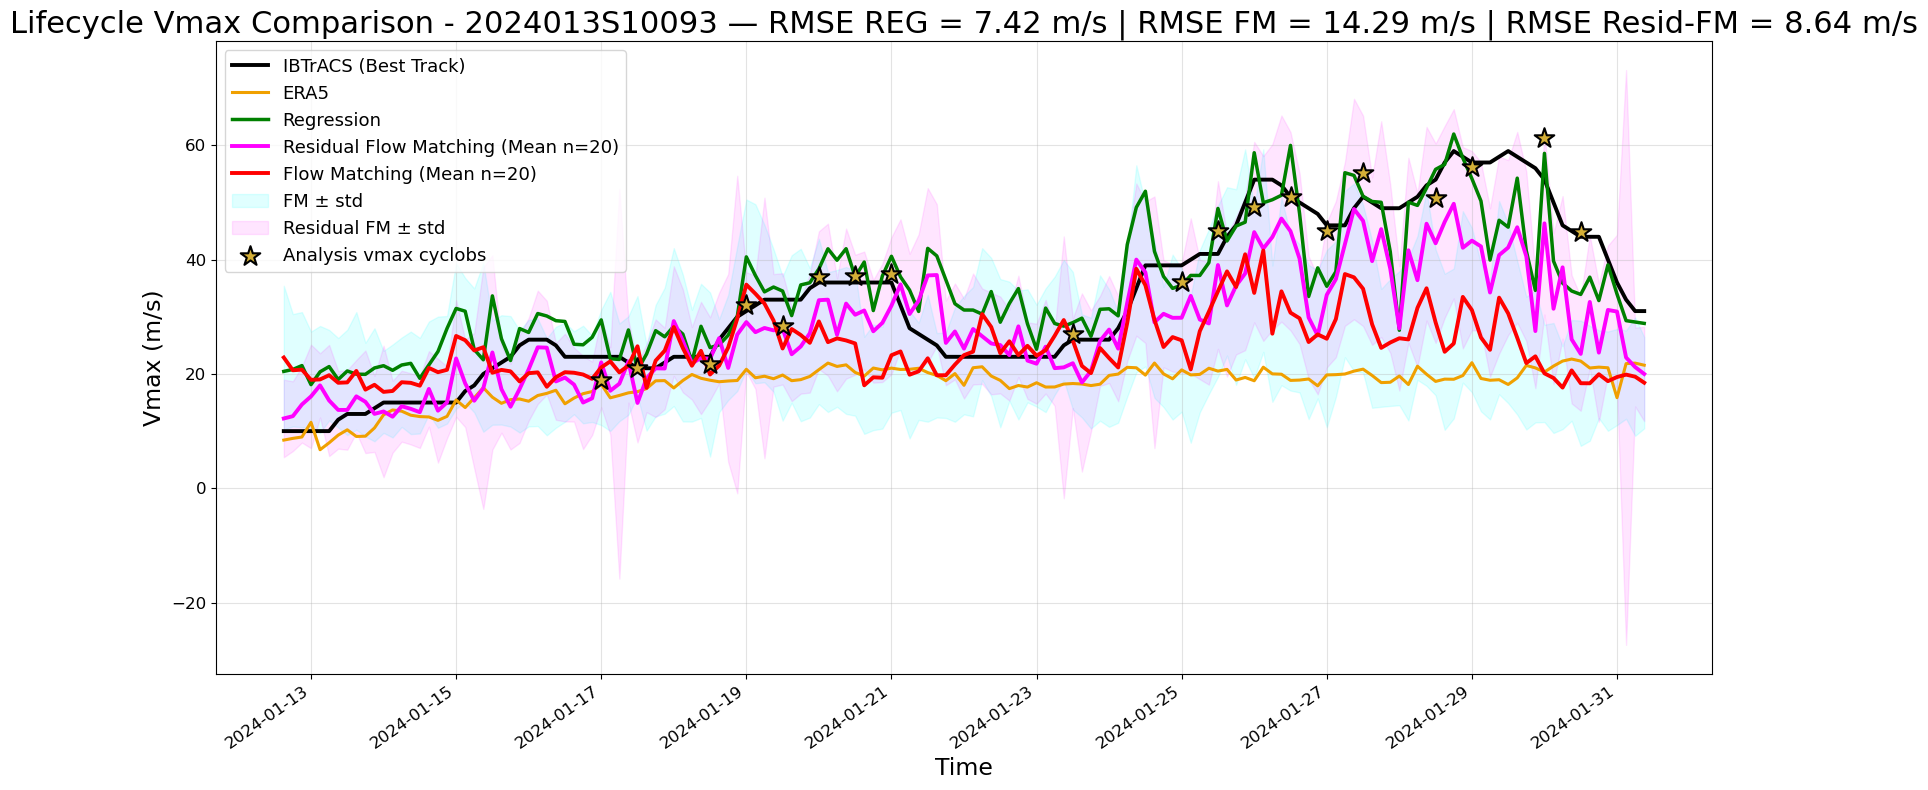

In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# --- Load CSV ---
anggrek_csv = pd.read_csv(
    "/scale/user/mtannaou/alternance/src/IR_to_SAR/ML_IR_SAR/csv_data/anggrek_coloc_sar_ir.csv"
)

# --- Dates + reference series ---
dates = pd.to_datetime(anggrek_csv["date"][1:-1].values)
ibtracs = anggrek_csv["ibtracs_vmax"][1:-1].astype(float).values

# Optional series if present in CSV
atcf = anggrek_csv["atcf_vmax"][1:-1].astype(float).values if "atcf_vmax" in anggrek_csv.columns else None
satcon = anggrek_csv["satcon_vmax"][1:-1].astype(float).values if "satcon_vmax" in anggrek_csv.columns else None
era5_ref = anggrek_csv["era5_vmax"][1:-1].astype(float).values if "era5_vmax" in anggrek_csv.columns else None
analysis_cyclobs = anggrek_csv["analysis_vmax_cyclobs"][1:-1].astype(float).values if "analysis_vmax_cyclobs" in anggrek_csv.columns else None
cyclobs = anggrek_csv["vmax_cyclobs"][1:-1].astype(float).values if "vmax_cyclobs" in anggrek_csv.columns else None

print(len(ibtracs), len(dates))

# --- Compute vmax for predictions ---
mean_fm_vmax, std_fm_vmax = [], []
reg_vmax = []
mean_res_fm_vmax, std_res_fm_vmax = [], []

for sar in reg_pred_anggrek:
    reg_vmax.append(np.nanmax(np.squeeze(sar)))
reg_vmax = np.array(reg_vmax)

for sar_mean, sar_std in zip(pred_fm_mean_anggrek, pred_fm_std_anggrek):
    mean_fm_vmax.append(np.nanmax(np.squeeze(sar_mean)))
    std_fm_vmax.append(np.nanmax(np.squeeze(sar_std)))
mean_fm_vmax = np.array(mean_fm_vmax)
std_fm_vmax = np.array(std_fm_vmax)

for sar_mean, sar_std in zip(pred_residual_fm_anggrek_mean_denorm, pred_residual_fm_anggrek_std_denorm):
    mean_res_fm_vmax.append(np.nanmax(np.squeeze(sar_mean)))
    std_res_fm_vmax.append(np.nanmax(np.squeeze(sar_std)))
mean_res_fm_vmax = np.array(mean_res_fm_vmax)
std_res_fm_vmax = np.array(std_res_fm_vmax)

print("Regression vmax :", reg_vmax.shape)
print("Flow matching vmax :", mean_fm_vmax.shape)
print("Residual Flow matching vmax :", mean_res_fm_vmax.shape)

# --- Safety: align lengths ---
n = min(
    len(dates),
    len(ibtracs),
    len(reg_vmax),
    len(mean_fm_vmax),
    len(mean_res_fm_vmax),
)

dates = dates[:n]
ibtracs = ibtracs[:n]
reg_vmax = reg_vmax[:n]
mean_fm_vmax = mean_fm_vmax[:n]
std_fm_vmax = std_fm_vmax[:n]
mean_res_fm_vmax = mean_res_fm_vmax[:n]
std_res_fm_vmax = std_res_fm_vmax[:n]

if atcf is not None:
    atcf = atcf[:n]
if satcon is not None:
    satcon = satcon[:n]
if era5_ref is not None:
    era5_ref = era5_ref[:n]
if analysis_cyclobs is not None:
    analysis_cyclobs = analysis_cyclobs[:n]
if cyclobs is not None:
    cyclobs = cyclobs[:n]

# --- RMSE against IBTrACS ---
rmse_reg = np.sqrt(np.nanmean((reg_vmax - ibtracs) ** 2))
rmse_fm = np.sqrt(np.nanmean((mean_fm_vmax - ibtracs) ** 2))
rmse_resfm = np.sqrt(np.nanmean((mean_res_fm_vmax - ibtracs) ** 2))

# --- Plot ---
fig, ax = plt.subplots(figsize=(16, 8))

# Main curves
ax.plot(dates, ibtracs, color="black", linewidth=2.8, label="IBTrACS (Best Track)")

if era5_ref is not None:
    ax.plot(dates, era5_ref, color="#f0a000", linewidth=2.2, label="ERA5")

ax.plot(dates, reg_vmax, color="green", linewidth=2.5, label="Regression")
ax.plot(dates, mean_res_fm_vmax, color="magenta", linewidth=2.8, label="Residual Flow Matching (Mean n=20)")
ax.plot(dates, mean_fm_vmax, color="red", linewidth=2.8, label="Flow Matching (Mean n=20)")

# Optional uncertainty bands
ax.fill_between(
    dates,
    mean_fm_vmax - std_fm_vmax,
    mean_fm_vmax + std_fm_vmax,
    color="cyan",
    alpha=0.12,
    label="FM ± std"
)

ax.fill_between(
    dates,
    mean_res_fm_vmax - std_res_fm_vmax,
    mean_res_fm_vmax + std_res_fm_vmax,
    color="magenta",
    alpha=0.10,
    label="Residual FM ± std"
)

# Cyclobs markers if available
if analysis_cyclobs is not None:
    valid = np.isfinite(analysis_cyclobs)
    ax.scatter(
        dates[valid],
        analysis_cyclobs[valid],
        marker="*",
        s=220,
        facecolor="#d4af37",
        edgecolor="black",
        linewidth=1.5,
        label="Analysis vmax cyclobs",
        zorder=6
    )

# Formatting
storm_id = "2024013S10093"
ax.set_title(
    f"Lifecycle Vmax Comparison - {storm_id} — RMSE REG = {rmse_reg:.2f} m/s | "
    f"RMSE FM = {rmse_fm:.2f} m/s | RMSE Resid-FM = {rmse_resfm:.2f} m/s",
    fontsize=22
)

ax.set_xlabel("Time", fontsize=17)
ax.set_ylabel("Vmax (m/s)", fontsize=17)

ax.grid(True, alpha=0.35)
ax.legend(loc="upper left", fontsize=13, frameon=True)

ax.xaxis.set_major_locator(mdates.DayLocator(interval=2))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
plt.xticks(rotation=35, ha="right", fontsize=12)
plt.yticks(fontsize=12)

plt.tight_layout()
plt.show()

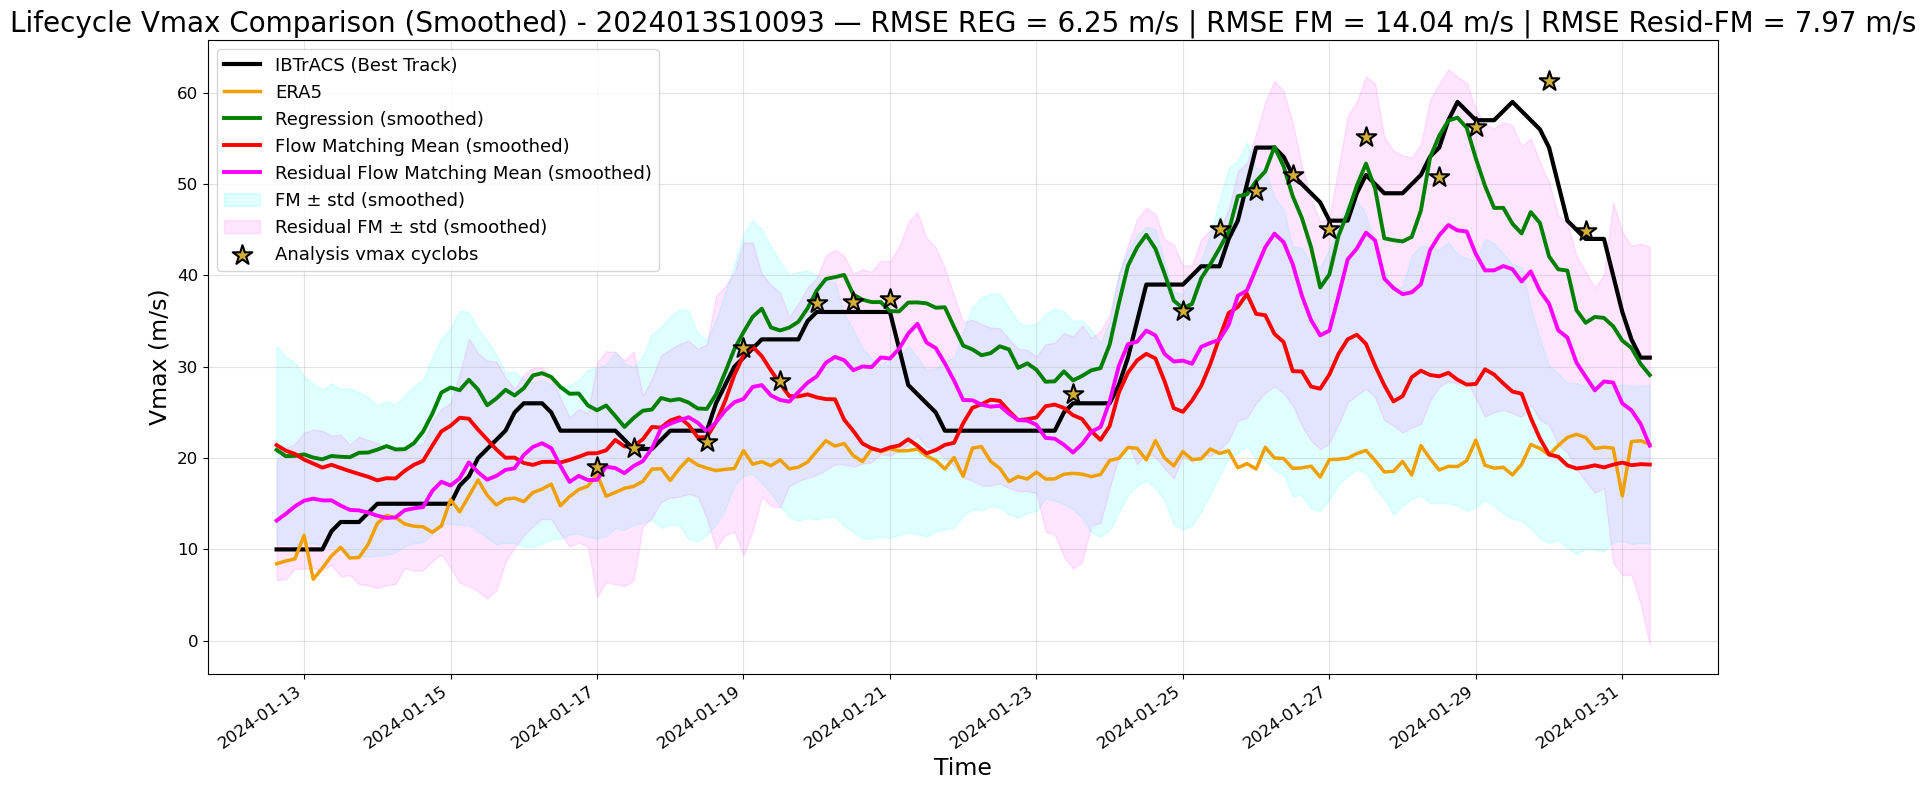

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# --- Load CSV ---
anggrek_csv = pd.read_csv(
    "/scale/user/mtannaou/alternance/src/IR_to_SAR/ML_IR_SAR/csv_data/anggrek_coloc_sar_ir.csv"
)

# --- Dates + reference series ---
dates = pd.to_datetime(anggrek_csv["date"][1:-1].values)
ibtracs = anggrek_csv["ibtracs_vmax"][1:-1].astype(float).values

era5_ref = anggrek_csv["era5_vmax"][1:-1].astype(float).values if "era5_vmax" in anggrek_csv.columns else None
analysis_cyclobs = anggrek_csv["analysis_vmax_cyclobs"][1:-1].astype(float).values if "analysis_vmax_cyclobs" in anggrek_csv.columns else None

# --- Compute vmax for predictions ---
mean_fm_vmax, std_fm_vmax = [], []
reg_vmax = []
mean_res_fm_vmax, std_res_fm_vmax = [], []

for sar in reg_pred_anggrek:
    reg_vmax.append(np.nanmax(np.squeeze(sar)))
reg_vmax = np.array(reg_vmax)

for sar_mean, sar_std in zip(pred_fm_mean_anggrek, pred_fm_std_anggrek):
    mean_fm_vmax.append(np.nanmax(np.squeeze(sar_mean)))
    std_fm_vmax.append(np.nanmax(np.squeeze(sar_std)))
mean_fm_vmax = np.array(mean_fm_vmax)
std_fm_vmax = np.array(std_fm_vmax)

for sar_mean, sar_std in zip(pred_residual_fm_anggrek_mean_denorm, pred_residual_fm_anggrek_std_denorm):
    mean_res_fm_vmax.append(np.nanmax(np.squeeze(sar_mean)))
    std_res_fm_vmax.append(np.nanmax(np.squeeze(sar_std)))
mean_res_fm_vmax = np.array(mean_res_fm_vmax)
std_res_fm_vmax = np.array(std_res_fm_vmax)

# --- Safety: align lengths ---
n = min(
    len(dates),
    len(ibtracs),
    len(reg_vmax),
    len(mean_fm_vmax),
    len(mean_res_fm_vmax),
)

dates = dates[:n]
ibtracs = ibtracs[:n]
reg_vmax = reg_vmax[:n]
mean_fm_vmax = mean_fm_vmax[:n]
std_fm_vmax = std_fm_vmax[:n]
mean_res_fm_vmax = mean_res_fm_vmax[:n]
std_res_fm_vmax = std_res_fm_vmax[:n]

if era5_ref is not None:
    era5_ref = era5_ref[:n]
if analysis_cyclobs is not None:
    analysis_cyclobs = analysis_cyclobs[:n]

# --- Centered moving average: 2 before, current, 2 after ---
def smooth_series(x, window=5):
    return pd.Series(x).rolling(window=window, center=True, min_periods=1).mean().to_numpy()

reg_vmax_smooth = smooth_series(reg_vmax, window=5)
mean_fm_vmax_smooth = smooth_series(mean_fm_vmax, window=5)
mean_res_fm_vmax_smooth = smooth_series(mean_res_fm_vmax, window=5)

if era5_ref is not None:
    era5_ref_smooth = era5_ref

# Optional: smooth std too if you want smoother uncertainty bands
std_fm_vmax_smooth = smooth_series(std_fm_vmax, window=5)
std_res_fm_vmax_smooth = smooth_series(std_res_fm_vmax, window=5)

# --- RMSE against IBTrACS using smoothed curves ---
rmse_reg = np.sqrt(np.nanmean((reg_vmax_smooth - ibtracs) ** 2))
rmse_fm = np.sqrt(np.nanmean((mean_fm_vmax_smooth - ibtracs) ** 2))
rmse_resfm = np.sqrt(np.nanmean((mean_res_fm_vmax_smooth - ibtracs) ** 2))

# --- Plot ---
fig, ax = plt.subplots(figsize=(16, 8))

# IBTrACS kept raw
ax.plot(dates, ibtracs, color="black", linewidth=3.0, label="IBTrACS (Best Track)")

# Smoothed ERA5
if era5_ref is not None:
    ax.plot(dates, era5_ref_smooth, color="#f0a000", linewidth=2.5, label="ERA5")

# Smoothed model curves only
ax.plot(dates, reg_vmax_smooth, color="green", linewidth=2.8, label="Regression (smoothed)")
ax.plot(dates, mean_fm_vmax_smooth, color="red", linewidth=2.8, label="Flow Matching Mean (smoothed)")
ax.plot(dates, mean_res_fm_vmax_smooth, color="magenta", linewidth=2.8, label="Residual Flow Matching Mean (smoothed)")

# Optional smoothed uncertainty bands
ax.fill_between(
    dates,
    mean_fm_vmax_smooth - std_fm_vmax_smooth,
    mean_fm_vmax_smooth + std_fm_vmax_smooth,
    color="cyan",
    alpha=0.12,
    label="FM ± std (smoothed)"
)

ax.fill_between(
    dates,
    mean_res_fm_vmax_smooth - std_res_fm_vmax_smooth,
    mean_res_fm_vmax_smooth + std_res_fm_vmax_smooth,
    color="magenta",
    alpha=0.10,
    label="Residual FM ± std (smoothed)"
)

# Cyclobs markers if available
if analysis_cyclobs is not None:
    valid = np.isfinite(analysis_cyclobs)
    ax.scatter(
        dates[valid],
        analysis_cyclobs[valid],
        marker="*",
        s=220,
        facecolor="#d4af37",
        edgecolor="black",
        linewidth=1.5,
        label="Analysis vmax cyclobs",
        zorder=6
    )

storm_id = "2024013S10093"
ax.set_title(
    f"Lifecycle Vmax Comparison (Smoothed) - {storm_id} — "
    f"RMSE REG = {rmse_reg:.2f} m/s | "
    f"RMSE FM = {rmse_fm:.2f} m/s | "
    f"RMSE Resid-FM = {rmse_resfm:.2f} m/s",
    fontsize=20
)

ax.set_xlabel("Time", fontsize=17)
ax.set_ylabel("Vmax (m/s)", fontsize=17)

ax.grid(True, alpha=0.35)
ax.legend(loc="upper left", fontsize=13, frameon=True)

ax.xaxis.set_major_locator(mdates.DayLocator(interval=2))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
plt.xticks(rotation=35, ha="right", fontsize=12)
plt.yticks(fontsize=12)

plt.tight_layout()
plt.show()

In [ ]:
#Anggrek plots for 25-01-2024  (99 --> )
anggrek_ir.shape
reg_pred_anggrek.shape
pred_fm_mean_anggrek.shape
pred_residual_fm_anggrek_mean_denorm.shape

(151, 1, 128, 128)

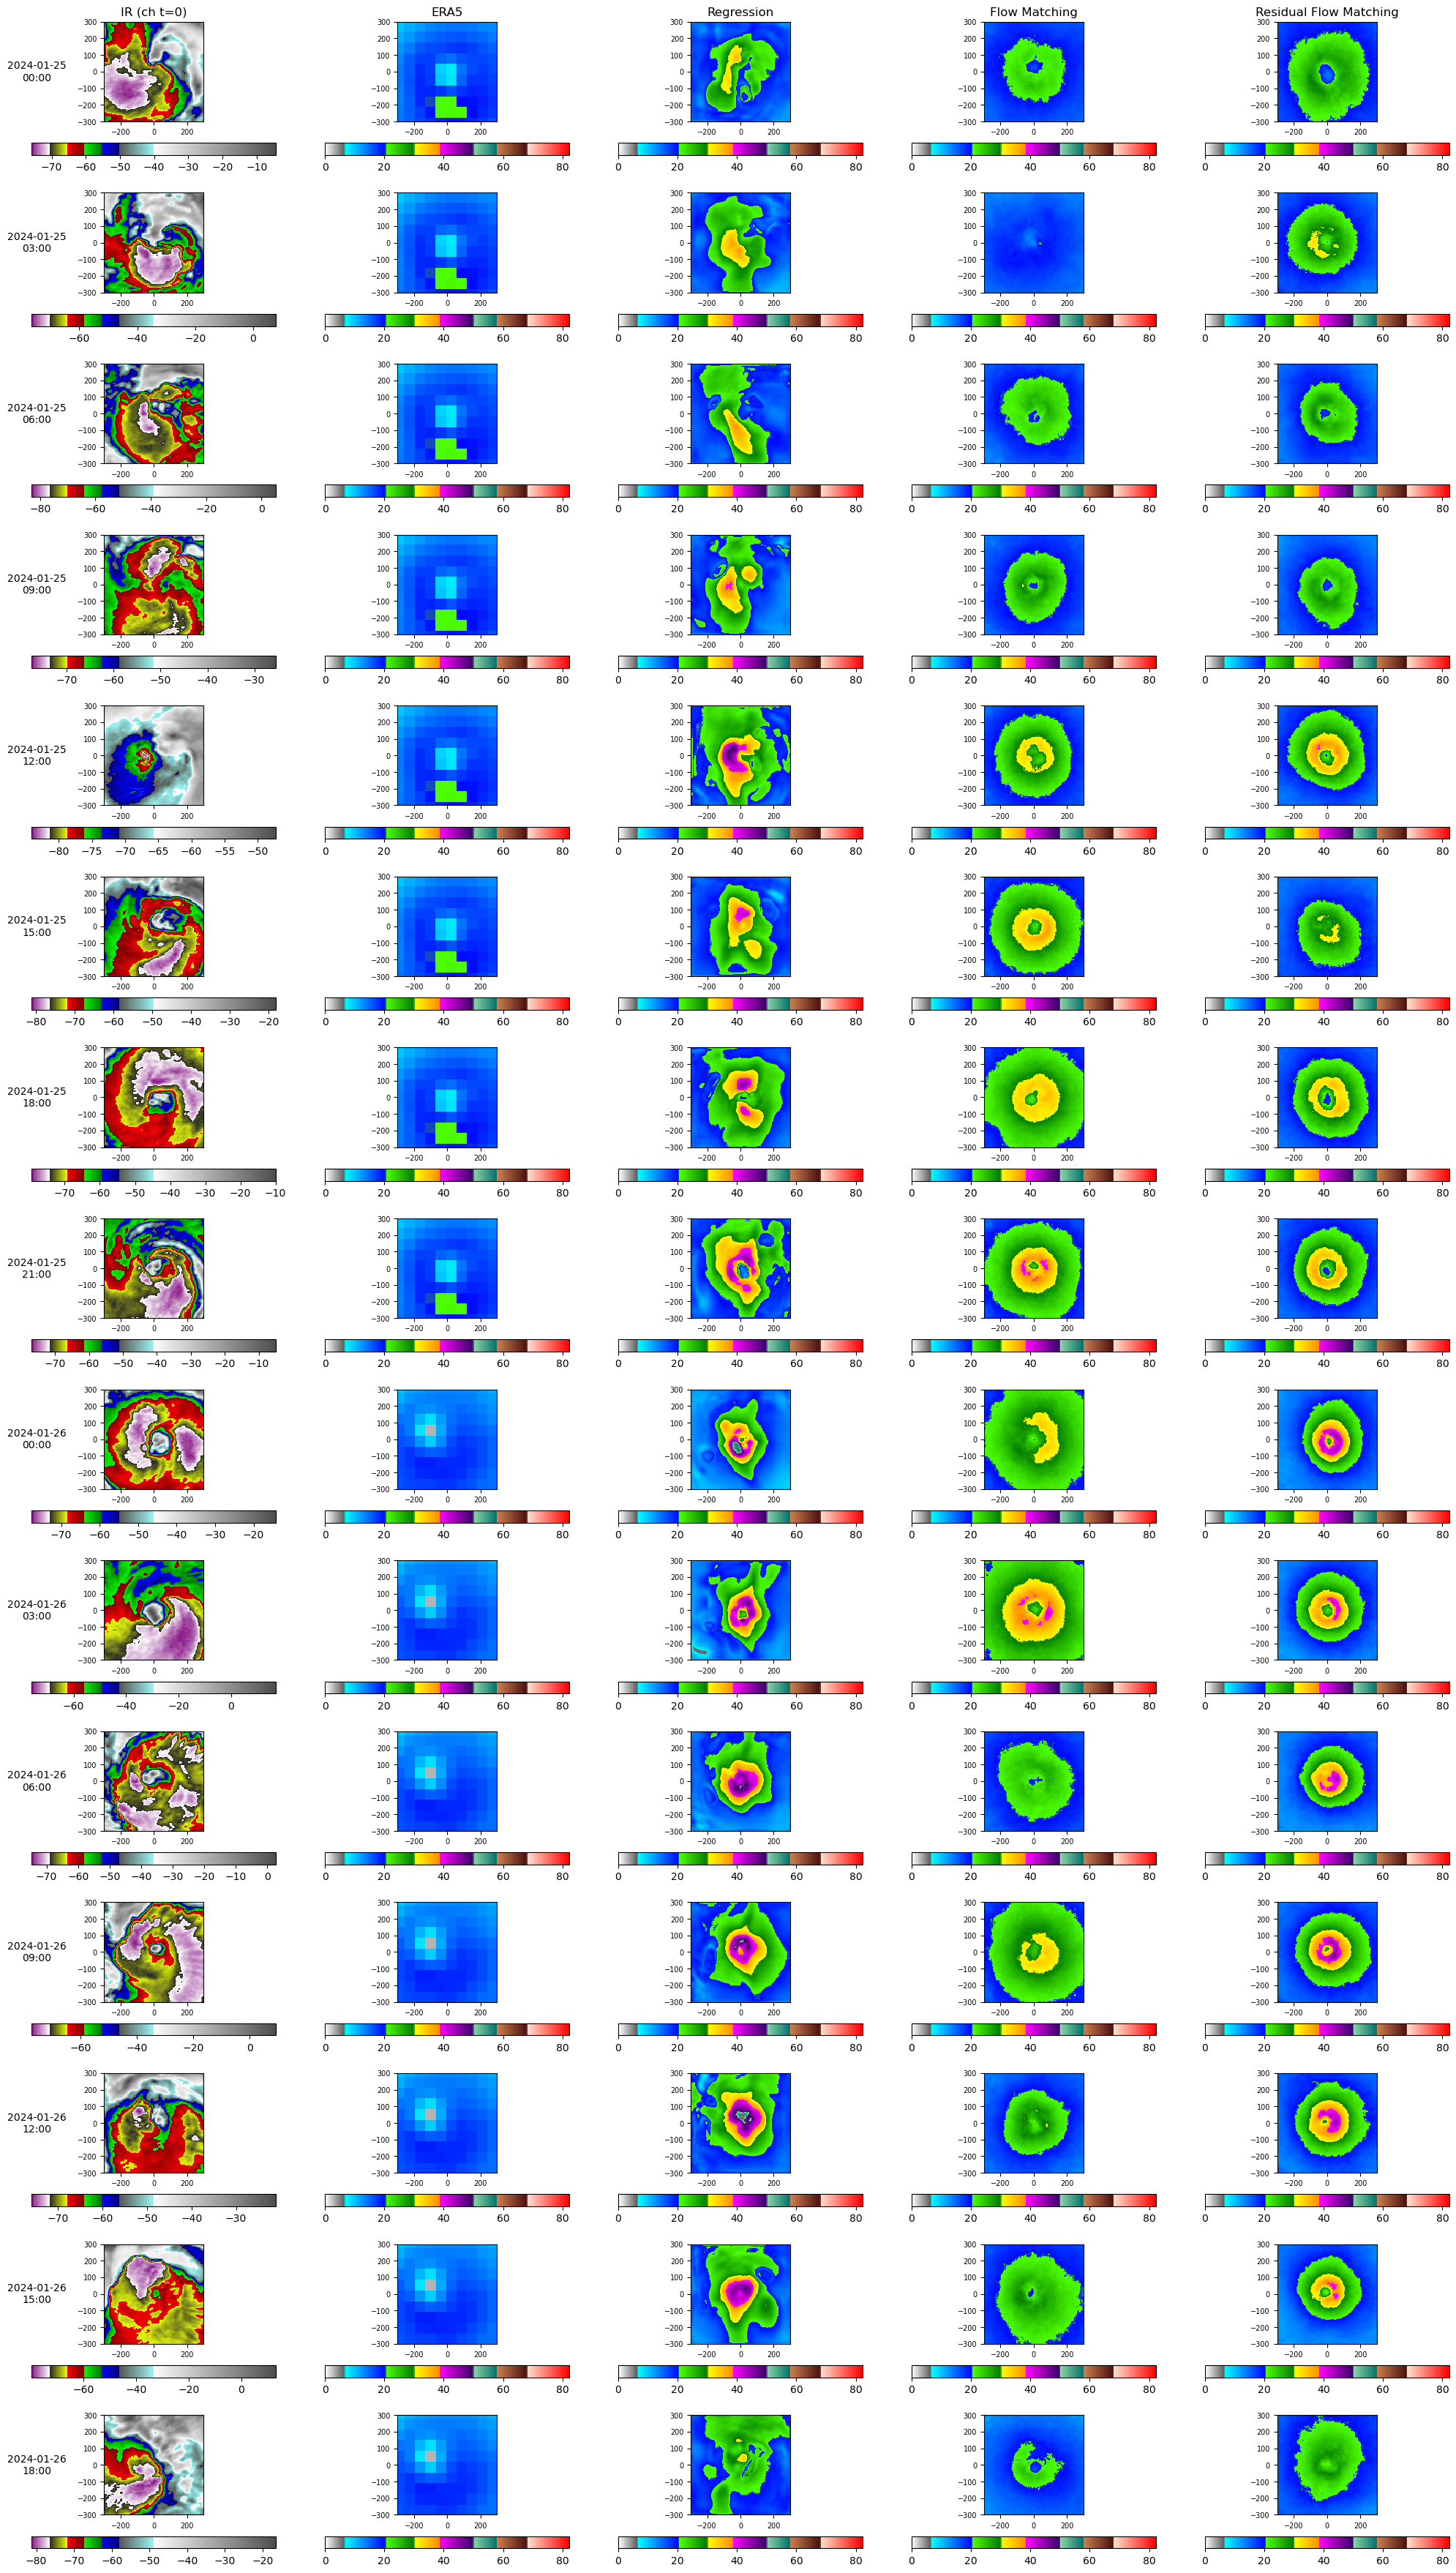

In [35]:
fig, axes = plt.subplots(15, 5, figsize=(25, 45))
for j in range(15):
    i = j + 99

    date = dates[i]
    ir = anggrek_ir[i, 4].squeeze()
    era5_i = era5_anggrek[i].squeeze()
    regression = reg_pred_anggrek[i].squeeze()
    fm_mean = pred_fm_mean_anggrek[i].squeeze()
    res_fm_mean = pred_residual_fm_anggrek_mean_denorm[i].squeeze()

    # Column 1: IR
    plot_ir(ir, fig=fig, ax=axes[j, 0])

    # Column 2: ERA5
    plot_sar(era5_i, fig=fig, ax=axes[j, 1])

    # Column 3: Regression
    plot_sar(regression, fig=fig, ax=axes[j, 2])

    # Column 4: Flow Matching mean
    plot_sar(fm_mean, fig=fig, ax=axes[j, 3])

    # Column 5: Residual FM mean
    plot_sar(res_fm_mean, fig=fig, ax=axes[j, 4])

    # Titles only on first row
    if j == 0:
        axes[j, 0].set_title("IR (ch t=0)", fontsize=12)
        axes[j, 1].set_title("ERA5", fontsize=12)
        axes[j, 2].set_title("Regression", fontsize=12)
        axes[j, 3].set_title("Flow Matching", fontsize=12)
        axes[j, 4].set_title("Residual Flow Matching", fontsize=12)

    # Put the date on the left of each row
    axes[j, 0].set_ylabel(
        pd.to_datetime(date).strftime("%Y-%m-%d\n%H:%M"),
        fontsize=10,
        rotation=0,
        labelpad=40,
        va="center"
    )

    # Optional: reduce tick clutter
    for k in range(5):
        axes[j, k].tick_params(labelsize=7)

plt.show()